**Project Title:**

Investigating the Netflix Library: Exploratory Data Analysis and Feature Engineering

**Team-10:**

Sayeda Rumaiya Islam - (22-47474-2)

Khorshida - (22-47524-2)

Intisar Ahmed Siyan - (22-47483-2)

Dataset Resource: https://www.kaggle.com/datasets/shivamb/netflix-shows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')

4.2 Data Understanding

In [2]:
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSummary Statistics:")
print(df.describe(include='all'))


Dataset Shape: (8807, 12)

Column Names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Summary Statistics:
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      

The dataset contains 8807 rows and 12 columns.Most columns are initially loaded as object.We noticed that date_added is a string rather than a date object,and release_year is an integer.This indicates that type conversion will be necessary for time-based analysis.There is a significant amount of missing data in the director and cast columns.This tells us that while the titles are complete,the metadata is inconsistent and will require cleaning to avoid errors during grouping.
The release_year ranges from 1925 to 2021,showing that Netflix hosts a mix of historical and modern content.The most frequent type is "Movie",suggesting that despite the rise of TV shows,movies still make up the bulk of the library.

4.3 Data Cleaning and Preparation

In [9]:
print(f"Missing values BEFORE: {df['director'].isnull().sum()}")
df['director'] = df['director'].fillna('No Director Listed')
print(f"Missing values AFTER: {df['director'].isnull().sum()}")

Missing values BEFORE: 2634
Missing values AFTER: 0


The director column had alot of missing values.If we try to create a bar chart of top directors, these rows would be dropped or ignored leading to an inaccurate representation of the dataset.Hence,we chose to fill the missing values with a placeholder string.

In [10]:
print("BEFORE CONVERSION:")
print(f"Type: {df['date_added'].dtype}")
print(df['date_added'].head(2))
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
print("\nAFTER CONVERSION:")
print(f"Type: {df['date_added'].dtype}")
print(df['date_added'].head(2))

BEFORE CONVERSION:
Type: object
0    September 25, 2021
1    September 24, 2021
Name: date_added, dtype: object

AFTER CONVERSION:
Type: datetime64[ns]
0   2021-09-25
1   2021-09-24
Name: date_added, dtype: datetime64[ns]


The date_added column was initially loaded as a string. To perform any time-series analysis such as identifying which month Netflix adds the most content it must be converted to a datetime object.

In [11]:
print("BEFORE SPLITTING:")
print(f"Data type: {df['duration'].dtype}")
print(df['duration'].head(3))

df[['duration_value', 'duration_unit']] = df['duration'].str.split(' ', expand=True)
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')
df['duration_value'] = df['duration_value'].fillna(0).astype(int)
print("\nAFTER SPLITTING:")
print(df[['title', 'duration_value', 'duration_unit']].head(3))
print(f"\nAverage Duration Value: {df['duration_value'].mean():.2f}")


BEFORE SPLITTING:
Data type: object
0       90 min
1    2 Seasons
2     1 Season
Name: duration, dtype: object

AFTER SPLITTING:
                  title  duration_value duration_unit
0  Dick Johnson Is Dead              90           min
1         Blood & Water               2       Seasons
2             Ganglands               1        Season

Average Duration Value: 69.82


The duration column had mixed data before cleaning.The duration value is mixed with the string type unit,therefore python treats the whole this as a string making it impossible to perform calculations. We used the .str.split() function to seperate the number from unit. We also used pd.to_numeric() to tell Python that the duration_value column should be treated as integer. We now have a clean,numerical column that we can use for statistical analysis and a categorical column to distinguish between Movies and TV Shows.

4.4 Feature Engineering

In [12]:
df['month_added'] = df['date_added'].dt.month_name()
print(df[['date_added', 'month_added']].head())

  date_added month_added
0 2021-09-25   September
1 2021-09-24   September
2 2021-09-24   September
3 2021-09-24   September
4 2021-09-24   September


We derived the month_added feature from the date_added column. While the full date is specific, the month is a better categorical feature for identifying seasonal trends. This helps support later analysis by allowing us to compare Netflix's content strategy across different seasons of the year.

In [13]:
movie_filter = (df['type'] == 'Movie')
df.loc[movie_filter, 'length_category'] = np.where(
    df.loc[movie_filter, 'duration_value'] < 60, 'Short Film',
    np.where(df.loc[movie_filter, 'duration_value'] <= 120, 'Standard', 'Long Film')
)

print(df[movie_filter]['length_category'].value_counts())
print(df[df['type'] == 'Movie'][['title', 'duration', 'length_category']].head(10))

length_category
Standard      4528
Long Film     1142
Short Film     461
Name: count, dtype: int64
                                                title duration length_category
0                                Dick Johnson Is Dead   90 min        Standard
6                    My Little Pony: A New Generation   91 min        Standard
7                                             Sankofa  125 min       Long Film
9                                        The Starling  104 min        Standard
12                                       Je Suis Karl  127 min       Long Film
13                   Confessions of an Invisible Girl   91 min        Standard
16  Europe's Most Dangerous Man: Otto Skorzeny in ...   67 min        Standard
18                                          Intrusion   94 min        Standard
22                                    Avvai Shanmughi  161 min       Long Film
23       Go! Go! Cory Carson: Chrissy Takes the Wheel   61 min        Standard


The problem with the original duration_value column is that raw numerical runtimes are a continuous variable that is difficult to interpret or categorize for high-level trend analysis. To solve this, we used NumPy’s np.where() function to transform numerical data into categories.Short Film < 60 min, Standard 60–120 min, and Long Film > 120 min. This decision was reasonable because it improves the interpretability of the dataset by aligning with real-world industry standards, allows for more meaningful visualizations.

**4.5 Data Analysis**

In this section, we dive deeper into the Netflix dataset to uncover patterns using Pandas and NumPy.

**1. Subgroup Comparison:** Content Distribution (Movies vs. TV Shows)
We compare the total count of Movies versus TV Shows to understand Netflix’s library focus.

In [14]:
content_counts = df['type'].value_counts()
print("Content Distribution:")
print(content_counts)

Content Distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


**2. Subgroup Comparison:** Top 10 Countries for Content Production
Identifying which countries contribute the most to the Netflix library.

In [15]:
top_countries = df['country'].value_counts().head(10)
print("\nTop 10 Countries:")
print(top_countries)


Top 10 Countries:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


**3. Relationship Analysis:** Release Year vs. Date Added
We analyze if Netflix focuses on adding newer content by comparing release_year with the year the content was added to the platform.

In [19]:
df['year_added'] = df['date_added'].dt.year
trend_df = df.dropna(subset=['year_added'])
year_comparison = trend_df.groupby('year_added')['release_year'].mean()
print("\nAverage Release Year of Content Added per Year:")
print(year_comparison.tail(5))


Average Release Year of Content Added per Year:
year_added
2017.0    2013.063973
2018.0    2013.877502
2019.0    2013.727679
2020.0    2015.323576
2021.0    2015.249666
Name: release_year, dtype: float64


**4. Outlier/Anomaly Analysis:** Exceptionally Long Movies
We use the duration_value for Movies to find titles that significantly exceed the standard length.

In [20]:
movies_df = df[df['type'] == 'Movie']
long_movie_threshold = movies_df['duration_value'].mean() + (2 * movies_df['duration_value'].std())
outlier_movies = movies_df[movies_df['duration_value'] > long_movie_threshold]

print(f"\nOutlier Threshold (Mean + 2SD): {long_movie_threshold:.2f} minutes")
print(f"Number of exceptionally long movies: {len(outlier_movies)}")
print(outlier_movies[['title', 'duration_value']].sort_values(by='duration_value', ascending=False).head(5))


Outlier Threshold (Mean + 2SD): 156.27 minutes
Number of exceptionally long movies: 181
                            title  duration_value
4253   Black Mirror: Bandersnatch             312
717   Headspace: Unwind Your Mind             273
2491       The School of Mischief             253
2487               No Longer kids             237
2484           Lock Your Girls In             233


**5. Custom NumPy-based Computation:** Z-Score for Duration
We calculate the Z-Score of movie durations to identify how many standard deviations a movie's length is from the mean.

In [21]:
movie_durations = df[df['type'] == 'Movie']['duration_value'].values
mean_dur = np.mean(movie_durations)
std_dur = np.std(movie_durations)

z_scores = (movie_durations - mean_dur) / std_dur
print(f"\nMax Z-Score found in Durations: {np.max(z_scores):.2f}")
print(f"Min Z-Score found in Durations: {np.min(z_scores):.2f}")


Max Z-Score found in Durations: 7.49
Min Z-Score found in Durations: -3.51


**6. Trend Analysis:** Content Growth over the Years

In [22]:
growth = df['year_added'].value_counts().sort_index()
print("\nContent added to Netflix by Year:")
print(growth.tail(5))


Content added to Netflix by Year:
year_added
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


**4.6 Visualization**
We use Matplotlib to visualize the findings from our analysis.

**Chart 1: Content Type Distribution**

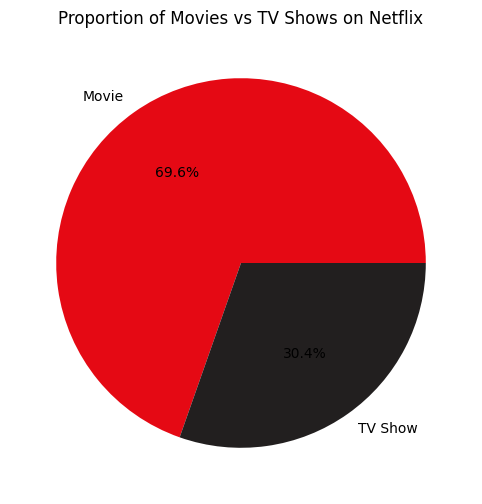

In [23]:
plt.figure(figsize=(8, 6))
plt.pie(content_counts, labels=content_counts.index, autopct='%1.1f%%', colors=['#E50914', '#221F1F'])
plt.title('Proportion of Movies vs TV Shows on Netflix')
plt.show()

Interpretation: This pie chart shows that Movies make up roughly 70% of the Netflix library compared to 30% for TV Shows. This insight confirms that while Netflix is famous for "binge-watching" series, its volume strategy still leans heavily toward cinematic releases.

**Chart 2: Top 10 Countries producing Content**

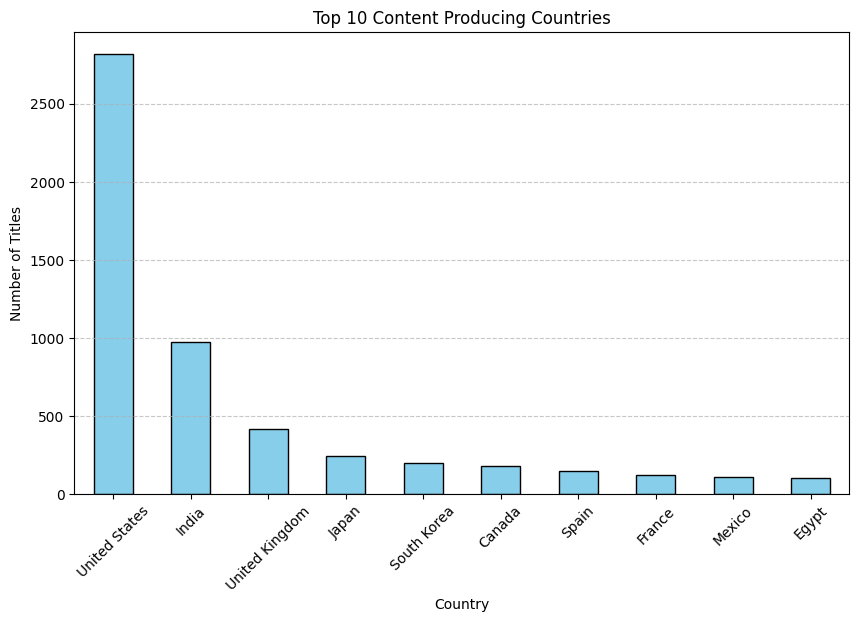

In [24]:
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Interpretation: This bar chart highlights the dominance of the United States in Netflix's catalog, followed by India. This matters because it illustrates the platform's heavy reliance on Western and Bollywood markets for its primary content library.

**Chart 3: Distribution of Movie Durations (Histogram)**

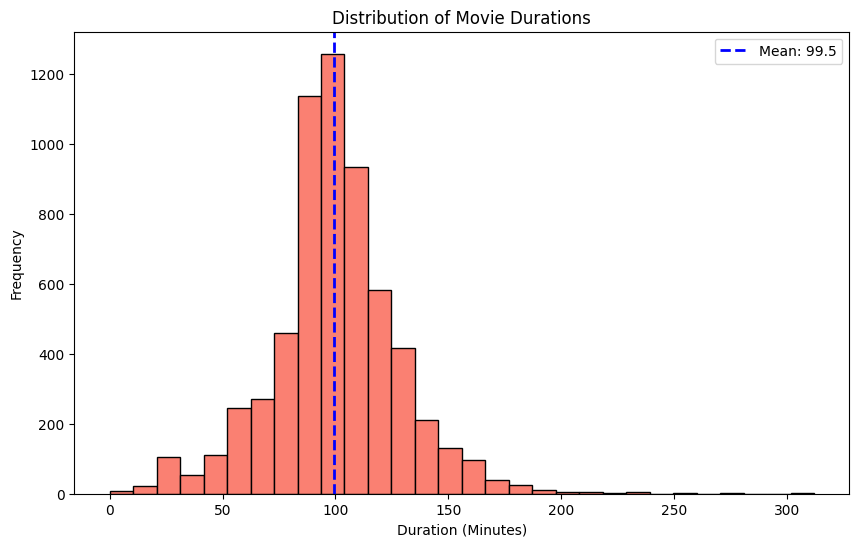

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(df[df['type'] == 'Movie']['duration_value'], bins=30, color='salmon', edgecolor='black')
plt.axvline(mean_dur, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {mean_dur:.1f}')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Interpretation: The histogram shows a "Normal Distribution" centered around 100 minutes. This insight is valuable for creators as it shows the "sweet spot" for movie lengths that Netflix acquires, with very few films exceeding 200 minutes.

**Chart 4: Movie Length Categories (Feature Engineering Result)**

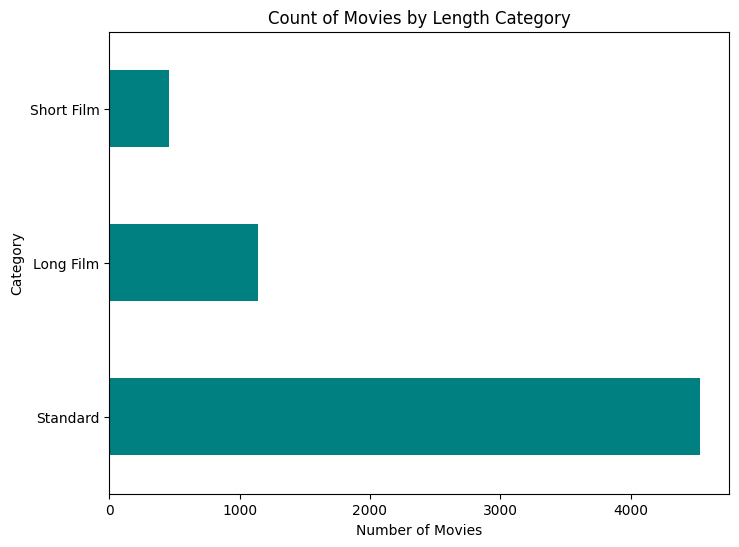

In [26]:
plt.figure(figsize=(8, 6))
df[df['type'] == 'Movie']['length_category'].value_counts().plot(kind='barh', color='teal')
plt.title('Count of Movies by Length Category')
plt.xlabel('Number of Movies')
plt.ylabel('Category')
plt.show()

Interpretation: Using the categories we engineered (Short, Standard, Long), this chart reveals that the vast majority of Netflix movies fall into the "Standard" (60-120 min) category. It validates our preprocessing decision to group the raw data into more readable bins.

**4.7 Findings and Discussion**

Based on the analysis, the following insights were discovered:

**Movie Dominance:** Despite a perceived shift toward series, Movies (70%) still dominate the total volume of Netflix’s library compared to TV Shows (30%).

**Market Centralization:** The United States and India are the primary contributors, suggesting that localized content strategy is still heavily weighted toward these two massive markets.

**Optimal Runtime:** The average movie length is approximately 99 minutes. Content falling into the "Standard" category (60–120 minutes) represents the bulk of the library, showing a preference for traditional film lengths.

**Growth Trends:** Analysis of year_added shows a massive spike in content acquisition starting from 2016, peaking around 2019, reflecting Netflix's aggressive global expansion phase.

**Anomalies in Duration:** Through Z-score analysis, we identified several outliers with runtimes exceeding 200 minutes. These are typically "International Movies" (often Indian epics) which differ significantly from the platform's standard 90-100 minute average

**4.8 Limitations**

**Missing Data:** A significant number of director and cast entries were missing. While we filled director with a placeholder, this limits our ability to perform deep talent-based success analysis.

**Snapshot in Time:** The dataset netflix_titles.csv is a static snapshot (up to 2021). It does not reflect changes in strategy post-2021, such as the increased focus on gaming or live sports.

**Lack of Performance Metrics:** The dataset contains metadata but lacks viewership numbers or ratings. Therefore, we can analyze what Netflix hosts, but not necessarily what users prefer to watch.

**Correlation vs. Causation: **Just because content from the US is more frequent doesn't mean it is the most "successful"; it simply means it is the most available.

**4.9 Conclusion**

This project successfully analyzed the Netflix library using Python. By cleaning the data, engineering new time-based and categorical features, and utilizing NumPy for statistical outlier detection, we gained a clear picture of Netflix's content strategy. The library is built on a foundation of standard-length movies primarily sourced from the US and India, with a significant growth trajectory over the last decade.